# Data Analysis Mini Project

## Student Name: Azaan Ahmed Butt

This project performs Exploratory Data Analysis (EDA) using the Customers and Products datasets provided by Zynex Solutions.

The objective is to analyze customer purchasing behavior, product information, inventory value, discounts, and generate useful business insights.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

## Importing Libraries


In [9]:
customers = pd.read_csv("Customers.csv")
products = pd.read_csv("Products.csv")

In [10]:
customers.head()

,Customer_ID,Customer_Name,Contact_no,Email,Address,City,Country,Product_ID
0,C001,Joan Johnson,825-522-8959x935,schultzjohn@hotmail.com,"1639 Pamela Streets, New Emily, IN 04537",NaN,Barbados,P023
1,C002,Daniel Welch,762-020-3805x90140,kcarter@williams.com,"11086 Vasquez Cape Apt. 122, Joelmouth, IA 76054",Quinntown,Marshall Islands,P044
2,C003,Kristin Wolf,001-253-585-5846,julie22@yahoo.com,"4404 Morgan Wall, Darrellburgh, NC 21390",Watersland,Iraq,P089
3,C004,Kimberly Johnson,779-888-4859x165,andrewlee@gmail.com,"2412 Michael Estate, Veronicafort, NC 16962",Port Jennifer,New Caledonia,P012
4,C005,Juan Woodward,(832)416-1791,gabrielmills@olson.net,"872 Joseph Lakes, Rebeccahaven, TN 76169",East Steven,Gibraltar,P030


In [11]:
products.head()

,Product_ID,Product_Name,Quantity,Price,Discount
0,P001,Realize,878,249.81,15.0
1,P002,Process,471,263.44,NaN
2,P003,Nature,329,157.08,10.0
3,P004,Space,521,385.53,0.0
4,P005,Art,73,383.83,0.0


Pandas library is imported to read and manipulate datasets efficiently.

Matplotlib library is imported to create visualizations and charts for data analysis.

## Loading the Dataset
The Customers and Products datasets were loaded using the read_csv() function.

The head() method was used to display the first five records of each dataset and verify successful loading.

In [12]:
print(customers.shape)
print(products.shape)

(100, 8)
(100, 5)


## Dataset Dimensions

The shape attribute was used to determine the number of rows and columns in each dataset.

This helps understand the size of the data before performing analysis.

In [13]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    100 non-null    object 
 1   Product_Name  100 non-null    object 
 2   Quantity      100 non-null    int64  
 3   Price         100 non-null    float64
 4   Discount      88 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 4.0+ KB


## Dataset Information

The info() method was used to inspect the structure of the Products dataset.

This method provides:

- Column names
- Data types
- Number of non-null values

The analysis revealed that the Discount column contains some missing values which will be handled during further analysis.

In [14]:
products["Inventory_Value"] = products["Quantity"] * products["Price"]

In [15]:
products["Inventory_Value"]

0     219333.18
1     124080.24
2      51679.32
3     200861.13
4      28019.59
        ...    
95    154455.39
96    363359.22
97      7150.08
98     66759.00
99     72777.28
Name: Inventory_Value, Length: 100, dtype: float64

In [16]:
products.head()

,Product_ID,Product_Name,Quantity,Price,Discount,Inventory_Value
0,P001,Realize,878,249.81,15.0,219333.18
1,P002,Process,471,263.44,NaN,124080.24
2,P003,Nature,329,157.08,10.0,51679.32
3,P004,Space,521,385.53,0.0,200861.13
4,P005,Art,73,383.83,0.0,28019.59


## Task 1: Inventory Value Calculation

A new column named Inventory_Value was created by multiplying the Quantity and Price columns.

Formula:

Inventory Value = Quantity × Price

This calculation helps determine the monetary value of the available stock for each product.

In [17]:
total_inventory_value = products["Inventory_Value"].sum()

print("Total Inventory Value:", total_inventory_value)

Total Inventory Value: 13133737.88


## Total Inventory Value

The sum() method was used to calculate the total inventory value of all products.

Formula:

Total Inventory Value = Sum of (Quantity × Price)

The Inventory_Value column was created by multiplying Quantity and Price for each product. The sum() function was then applied to calculate the overall inventory value.

In [18]:
products["Inventory_Value"].describe()

count       100.000000
mean     131337.378800
std      112277.236682
min        1258.560000
25%       46357.875000
50%      102234.505000
75%      196490.245000
max      436430.160000
Name: Inventory_Value, dtype: float64

### Findings

The total inventory value of all products was calculated as 13,133,737.88.

Descriptive statistics were generated using the describe() method. The average inventory value was 131,337.38, while the highest inventory value was 436,430.16 and the lowest was 1,258.56.

## Task 2: Discounted Price Calculation


In [19]:
products["Discount"].isnull().sum()

np.int64(12)

In [20]:
products["Discount"] = products["Discount"].fillna(0)

In [21]:
products["Discount"].isnull().sum()

np.int64(0)

## Handling Missing Values

The Discount column contained 12 missing values.

The fillna(0) method was used to replace missing discount values with 0, ensuring accurate calculations during price analysis.

In [22]:
products["Final_Price"] = products["Price"] - (
    products["Price"] * products["Discount"] / 100
)

In [23]:
products.head()

,Product_ID,Product_Name,Quantity,Price,Discount,Inventory_Value,Final_Price
0,P001,Realize,878,249.81,15.0,219333.18,212.3385
1,P002,Process,471,263.44,0.0,124080.24,263.4400
2,P003,Nature,329,157.08,10.0,51679.32,141.3720
3,P004,Space,521,385.53,0.0,200861.13,385.5300
4,P005,Art,73,383.83,0.0,28019.59,383.8300



The Discount column contained 12 missing values. These missing values were replaced with 0 using the fillna() method.

A new column named Final_Price was created using the following formula:

Final Price = Price − (Price × Discount / 100)

This calculation provides the selling price of each product after applying the discount percentage.

## Task 3: Total Number of Products


In [24]:
products["Product_ID"].nunique()

100

In [25]:
total_products = products["Product_ID"].nunique()

print("Total Products:", total_products)

Total Products: 100



The nunique() method was used to count the unique Product_ID values.

This method ensures that duplicate product IDs are not counted multiple times, providing the actual number of distinct products available in the dataset.

## Findings

The Product_ID column contains 100 unique product records.

The nunique() method confirmed that all products in the dataset are distinct, resulting in a total product count of 100.

## Task 4: Filtering Customers

In [26]:
customers["City"].unique()

array([nan, 'Quinntown', 'Watersland', 'Port Jennifer', 'East Steven',
       'Bakerberg', 'Wademouth', 'North Lauraborough', 'Nelsonchester',
       'Michelleborough', 'Kimberlymouth', 'Raymondmouth', 'Johnmouth',
       'East Timothyside', 'Port Lauratown', 'Lake Sheliaville',
       'Adamsview', 'North Joshua', 'Wyattberg', 'Daviston',
       'East Amberhaven', 'South Anthonyfurt', 'Andersonstad',
       'Ramirezport', 'Debraberg', 'Lake Christopher', 'Craigbury',
       'Jamestown', 'Solishaven', 'Harperfurt', 'Laneview',
       'Faulknerland', 'North Walterbury', 'Lake Jason',
       'North Melissamouth', 'Lake Yolandamouth', 'Brownmouth',
       'Jasontown', 'New Tammyland', 'Tonimouth', 'Hollandstad',
       'Lake Cheryl', 'Davidside', 'Stewartview', 'New Michaelberg',
       'Samanthatown', 'Davilaville', 'Karenshire', 'Murphyburgh',
       'Frankhaven', 'Adamsville', 'Port Paulshire', 'Cooperside',
       'Brightville', 'East Erica', 'Josephport', 'West Kimberlyberg',
       '

In [27]:
customers["Country"].unique()

array(['Barbados', 'Marshall Islands', 'Iraq', 'New Caledonia',
       'Gibraltar', 'Indonesia', 'Senegal', "Cote d'Ivoire",
       'New Zealand', 'Sweden', 'Micronesia', 'India', 'Kazakhstan',
       'Cyprus', 'Brunei Darussalam', 'Congo', 'Estonia',
       'Slovakia (Slovak Republic)', 'Kiribati', 'Cambodia', 'Jordan',
       'Trinidad and Tobago', 'Iceland', 'Falkland Islands (Malvinas)',
       'Angola', 'Saint Pierre and Miquelon', 'Northern Mariana Islands',
       'Martinique', 'Saint Martin', 'Bahrain', 'Malawi', 'Slovenia',
       'Saint Helena', 'Kyrgyz Republic', 'French Guiana', 'Dominica',
       'Nauru', 'Uganda', 'Greenland', 'Seychelles', 'Thailand',
       'Cameroon', 'Bolivia', 'Botswana', 'Anguilla', 'Romania',
       'Suriname', 'Namibia', 'Malaysia', 'Jamaica', 'Austria', 'Italy',
       'Canada', 'Chile', 'United Kingdom', 'Tajikistan', 'Tokelau',
       'Dominican Republic', 'Guernsey', 'Burundi', 'Turkmenistan',
       'Nepal', 'Belize', 'Andorra', 'Kuwait', 'Ca

## Exploring Customer Locations

The unique() method was used to identify all distinct cities and countries present in the customer dataset.

This exploration helps determine which locations are available for filtering and further analysis.

In [29]:
customers[customers["City"] == "Quinntown"]


,Customer_ID,Customer_Name,Contact_no,Email,Address,City,Country,Product_ID
1,C002,Daniel Welch,762-020-3805x90140,kcarter@williams.com,"11086 Vasquez Cape Apt. 122, Joelmouth, IA 76054",Quinntown,Marshall Islands,P044


In [30]:
quinntown_customers = customers[
    customers["City"] == "Quinntown"
]

quinntown_customers

,Customer_ID,Customer_Name,Contact_no,Email,Address,City,Country,Product_ID
1,C002,Daniel Welch,762-020-3805x90140,kcarter@williams.com,"11086 Vasquez Cape Apt. 122, Joelmouth, IA 76054",Quinntown,Marshall Islands,P044


In [31]:
len(quinntown_customers)

1

## Filtering Customers by City

Customer records were filtered using a conditional statement.

The City column was compared against a selected city name, and only matching records were returned.

This technique is commonly used in business analytics to study customers from specific regions.

In [33]:
customers[customers["Country"] == "Iraq"]

,Customer_ID,Customer_Name,Contact_no,Email,Address,City,Country,Product_ID
2,C003,Kristin Wolf,001-253-585-5846,julie22@yahoo.com,"4404 Morgan Wall, Darrellburgh, NC 21390",Watersland,Iraq,P089


In [34]:
iraq_customers = customers[
    customers["Country"] == "Iraq"
]

iraq_customers

,Customer_ID,Customer_Name,Contact_no,Email,Address,City,Country,Product_ID
2,C003,Kristin Wolf,001-253-585-5846,julie22@yahoo.com,"4404 Morgan Wall, Darrellburgh, NC 21390",Watersland,Iraq,P089


In [36]:
len(iraq_customers)

1

In [37]:
quinntown_customers

,Customer_ID,Customer_Name,Contact_no,Email,Address,City,Country,Product_ID
1,C002,Daniel Welch,762-020-3805x90140,kcarter@williams.com,"11086 Vasquez Cape Apt. 122, Joelmouth, IA 76054",Quinntown,Marshall Islands,P044


In [38]:
len(quinntown_customers)

1

In [42]:
iraq_customers

,Customer_ID,Customer_Name,Contact_no,Email,Address,City,Country,Product_ID
2,C003,Kristin Wolf,001-253-585-5846,julie22@yahoo.com,"4404 Morgan Wall, Darrellburgh, NC 21390",Watersland,Iraq,P089


In [41]:
len(iraq_customers)

1



Customer records were filtered using conditional statements.

The City and Country columns were used to retrieve customers belonging to specific locations.

Results showed:

- 1 customer from Quinntown.
- 1 customer from Iraq.

Filtering allows analysts to perform region-based customer analysis and identify customer distribution across locations.

## Task 5: Most Purchased Product Category


In [43]:
products.columns

Index(['Product_ID', 'Product_Name', 'Quantity', 'Price', 'Discount',
       'Inventory_Value', 'Final_Price'],
      dtype='object')


The provided Products dataset does not contain a Product Category column.

After examining the dataset structure using the columns attribute, it was determined that category information is unavailable.

Therefore, identifying the most purchased product category could not be performed with the provided data.

## Task 6: Age Group Transformation


In [45]:
customers.columns

Index(['Customer_ID', 'Customer_Name', 'Contact_no', 'Email', 'Address',
       'City', 'Country', 'Product_ID'],
      dtype='object')


The Customers dataset was examined using the columns attribute.

No Age column was found in the dataset.

Since age information is unavailable, customer age groups (Teen, Young Adult, Adult, and Senior) could not be generated from the provided data.

## Task 7: Top 5 Cities with Most Purchases


In [46]:
customers["City"].value_counts().head(5)

City
North Joshua         2
Quinntown            1
Port Courtneyfort    1
Hillbury             1
Deniseton            1
Name: count, dtype: int64

In [47]:
top_cities = customers["City"].value_counts().head(5)

top_cities

City
North Joshua         2
Quinntown            1
Port Courtneyfort    1
Hillbury             1
Deniseton            1
Name: count, dtype: int64


The value_counts() method was used to count the number of purchases associated with each city.

The head(5) method was then applied to retrieve the five cities with the highest purchase counts.

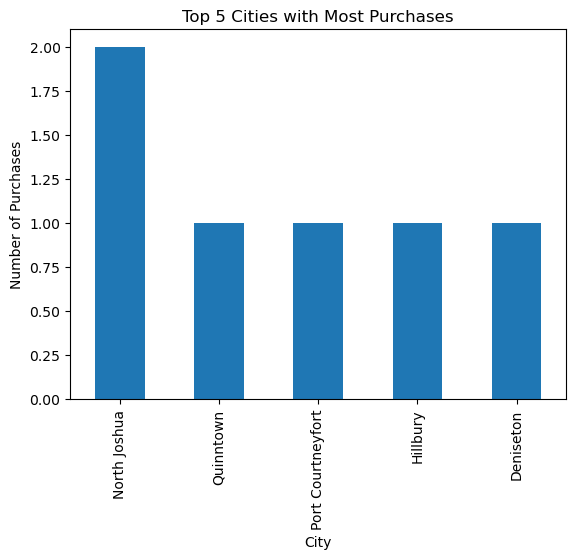

In [48]:
top_cities.plot(kind="bar")

plt.title("Top 5 Cities with Most Purchases")
plt.xlabel("City")
plt.ylabel("Number of Purchases")

plt.show()

## Visualization of Top Purchasing Cities

A bar chart was created to visualize the five cities with the highest number of purchases.

The plot() function was used with the bar chart option. Axis labels and a title were added to improve readability and presentation.

The visualization indicates that North Joshua recorded the highest number of purchases among all cities.

## Task 8: Customer Purchases by Product


In [56]:
merged_data = pd.merge(
    customers,
    products,
    on="Product_ID"
)

merged_data.head()

,Customer_ID,Customer_Name,Contact_no,Email,Address,City,Country,Product_ID,Product_Name,Quantity,Price,Discount,Inventory_Value,Final_Price
0,C001,Joan Johnson,825-522-8959x935,schultzjohn@hotmail.com,"1639 Pamela Streets, New Emily, IN 04537",NaN,Barbados,P023,Half,181,367.88,5.0,66586.28,349.4860
1,C002,Daniel Welch,762-020-3805x90140,kcarter@williams.com,"11086 Vasquez Cape Apt. 122, Joelmouth, IA 76054",Quinntown,Marshall Islands,P044,Position,675,279.93,5.0,188952.75,265.9335
2,C003,Kristin Wolf,001-253-585-5846,julie22@yahoo.com,"4404 Morgan Wall, Darrellburgh, NC 21390",Watersland,Iraq,P089,Suffer,639,376.83,0.0,240794.37,376.8300
3,C004,Kimberly Johnson,779-888-4859x165,andrewlee@gmail.com,"2412 Michael Estate, Veronicafort, NC 16962",Port Jennifer,New Caledonia,P012,Government,657,362.28,5.0,238017.96,344.1660
4,C005,Juan Woodward,(832)416-1791,gabrielmills@olson.net,"872 Joseph Lakes, Rebeccahaven, TN 76169",East Steven,Gibraltar,P030,Major,23,251.94,5.0,5794.62,239.3430


In [57]:
product_purchases = merged_data.groupby(
    "Product_Name"
)["Customer_ID"].count()

product_purchases

Product_Name
Activity      1
Always        1
Around        3
Art           1
Artist        1
             ..
Together      1
Understand    3
Whether       1
White         2
Why           1
Name: Customer_ID, Length: 63, dtype: int64


The groupby() method was used to group records by Product_Name.

The count() method was then applied to count the number of customers associated with each product.

The results were sorted in descending order using sort_values() to identify the most frequently purchased products.

In [58]:
product_purchases.sort_values(ascending=False)

Product_Name
Half          4
Own           4
Every         4
Around        3
Understand    3
             ..
Leader        1
Man           1
Meet          1
Always        1
Why           1
Name: Customer_ID, Length: 63, dtype: int64

## Findings

The customer purchase analysis revealed that some products were purchased by multiple customers.

The products "Half", "Own", and "Every" were the most purchased products, each being associated with 4 customers.

The products "Around" and "Understand" were purchased by 3 customers each.

This analysis helps identify popular products within the dataset.

## Task 9: Customer Purchase Report

In [67]:
merged_data["Final_Amount"] = (
    merged_data["Quantity"] *
    merged_data["Final_Price"]
)

report = merged_data[
    [
        "Customer_Name",
        "Product_Name",
        "Quantity",
        "Price",
        "Final_Amount"
    ]
]

report.head()

,Customer_Name,Product_Name,Quantity,Price,Final_Amount
0,Joan Johnson,Half,181,367.88,63256.9660
1,Daniel Welch,Position,675,279.93,179505.1125
2,Kristin Wolf,Suffer,639,376.83,240794.3700
3,Kimberly Johnson,Government,657,362.28,226117.0620
4,Juan Woodward,Major,23,251.94,5504.8890


A report was generated from the merged dataset.

The Final_Amount column was calculated by multiplying Quantity and Final_Price.

Relevant fields including Customer Name, Product Name, Quantity, Price, and Final Amount were selected to create a concise customer purchase report.

## Findings

A customer purchase report was generated using selected fields from the merged dataset.

The report includes customer names, product names, quantities, original prices, and final purchase amounts.

This report provides a concise overview of customer purchasing activity and product sales value.

## Task 10: Customers Purchasing Discounted Products


In [68]:
discount_customers = merged_data[
    merged_data["Discount"] > 0
]

discount_customers

,Customer_ID,Customer_Name,Contact_no,Email,Address,City,Country,Product_ID,Product_Name,Quantity,Price,Discount,Inventory_Value,Final_Price,Final_Amount
0,C001,Joan Johnson,825-522-8959x935,schultzjohn@hotmail.com,"1639 Pamela Streets, New Emily, IN 04537",NaN,Barbados,P023,Half,181,367.88,5.0,66586.28,349.4860,63256.9660
1,C002,Daniel Welch,762-020-3805x90140,kcarter@williams.com,"11086 Vasquez Cape Apt. 122, Joelmouth, IA 76054",Quinntown,Marshall Islands,P044,Position,675,279.93,5.0,188952.75,265.9335,179505.1125
3,C004,Kimberly Johnson,779-888-4859x165,andrewlee@gmail.com,"2412 Michael Estate, Veronicafort, NC 16962",Port Jennifer,New Caledonia,P012,Government,657,362.28,5.0,238017.96,344.1660,226117.0620
4,C005,Juan Woodward,(832)416-1791,gabrielmills@olson.net,"872 Joseph Lakes, Rebeccahaven, TN 76169",East Steven,Gibraltar,P030,Major,23,251.94,5.0,5794.62,239.3430,5504.8890
6,C007,Dr. Peggy Hanson,(473)687-2816,riveramatthew@gmail.com,"533 Norton Port, Lake Johnchester, AR 60695",Wademouth,Senegal,P047,Own,907,381.46,5.0,345984.22,362.3870,328685.0090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,C093,Lauren Hernandez,(401)672-1940x8141,colerandy@rice-mason.com,"5556 Peter Crest, North Debbie, NJ 47550",North Kimberly,New Zealand,P078,Artist,876,257.35,15.0,225438.60,218.7475,191622.8100
94,C095,Austin Mejia,506.734.8260x9629,amanda35@gmail.com,"573 Johnston Rest Apt. 439, Carolynfurt, GA 08619",Lake Williamview,Central African Republic,P057,Sit,684,83.69,10.0,57243.96,75.3210,51519.5640
97,C098,Gary Gonzalez II,393.109.8151x7631,jamesmary@greene.org,"25238 Taylor Pass, Virginiaburgh, AZ 82648",New Danaton,Libyan Arab Jamahiriya,P053,Republican,102,217.29,10.0,22163.58,195.5610,19947.2220
98,C099,Lauren Fields,+1-806-578-9039x3247,adamsrichard@rodriguez.com,"2931 Zimmerman Ridge, West Ericstad, KS 47538",Nicoleland,Trinidad and Tobago,P085,Person,48,266.26,15.0,12780.48,226.3210,10863.4080


In [69]:
discount_report = discount_customers[
    [
        "Customer_Name",
        "Product_Name",
        "Discount"
    ]
]

discount_report.head()

,Customer_Name,Product_Name,Discount
0,Joan Johnson,Half,5.0
1,Daniel Welch,Position,5.0
3,Kimberly Johnson,Government,5.0
4,Juan Woodward,Major,5.0
6,Dr. Peggy Hanson,Own,5.0


In [70]:
len(discount_report)

67


Records were filtered using the condition Discount > 0.

Only customers who purchased products with an active discount were selected.

The resulting report displays customer names, product names, and the discount percentage applied to each purchase.

In [71]:
report.to_csv(
    "Customer_Purchase_Report.csv",
    index=False
)

print("Report Exported Successfully")

Report Exported Successfully


# Project Conclusion

This project applied Exploratory Data Analysis (EDA) techniques using the Customers and Products datasets.

Key activities included:

- Data loading and inspection
- Inventory value calculation
- Discount price calculation
- Product counting
- Customer filtering by location
- Purchase trend visualization
- Product purchase analysis
- Customer purchase reporting
- Identification of discounted purchases

Several business insights were generated from the datasets. However, Tasks 5 and 6 could not be completed because the required Category and Age fields were not present in the provided datasets.

Overall, the project demonstrated the use of Pandas and Matplotlib for data cleaning, transformation, analysis, and visualization.